In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules
from lfp_spike_window_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [3]:
cell_num =42 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 42  
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 42

## Step 0: Get loaded data #CHANGE DIRECTORIES FOR CELL DATA

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp_filt.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'


In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

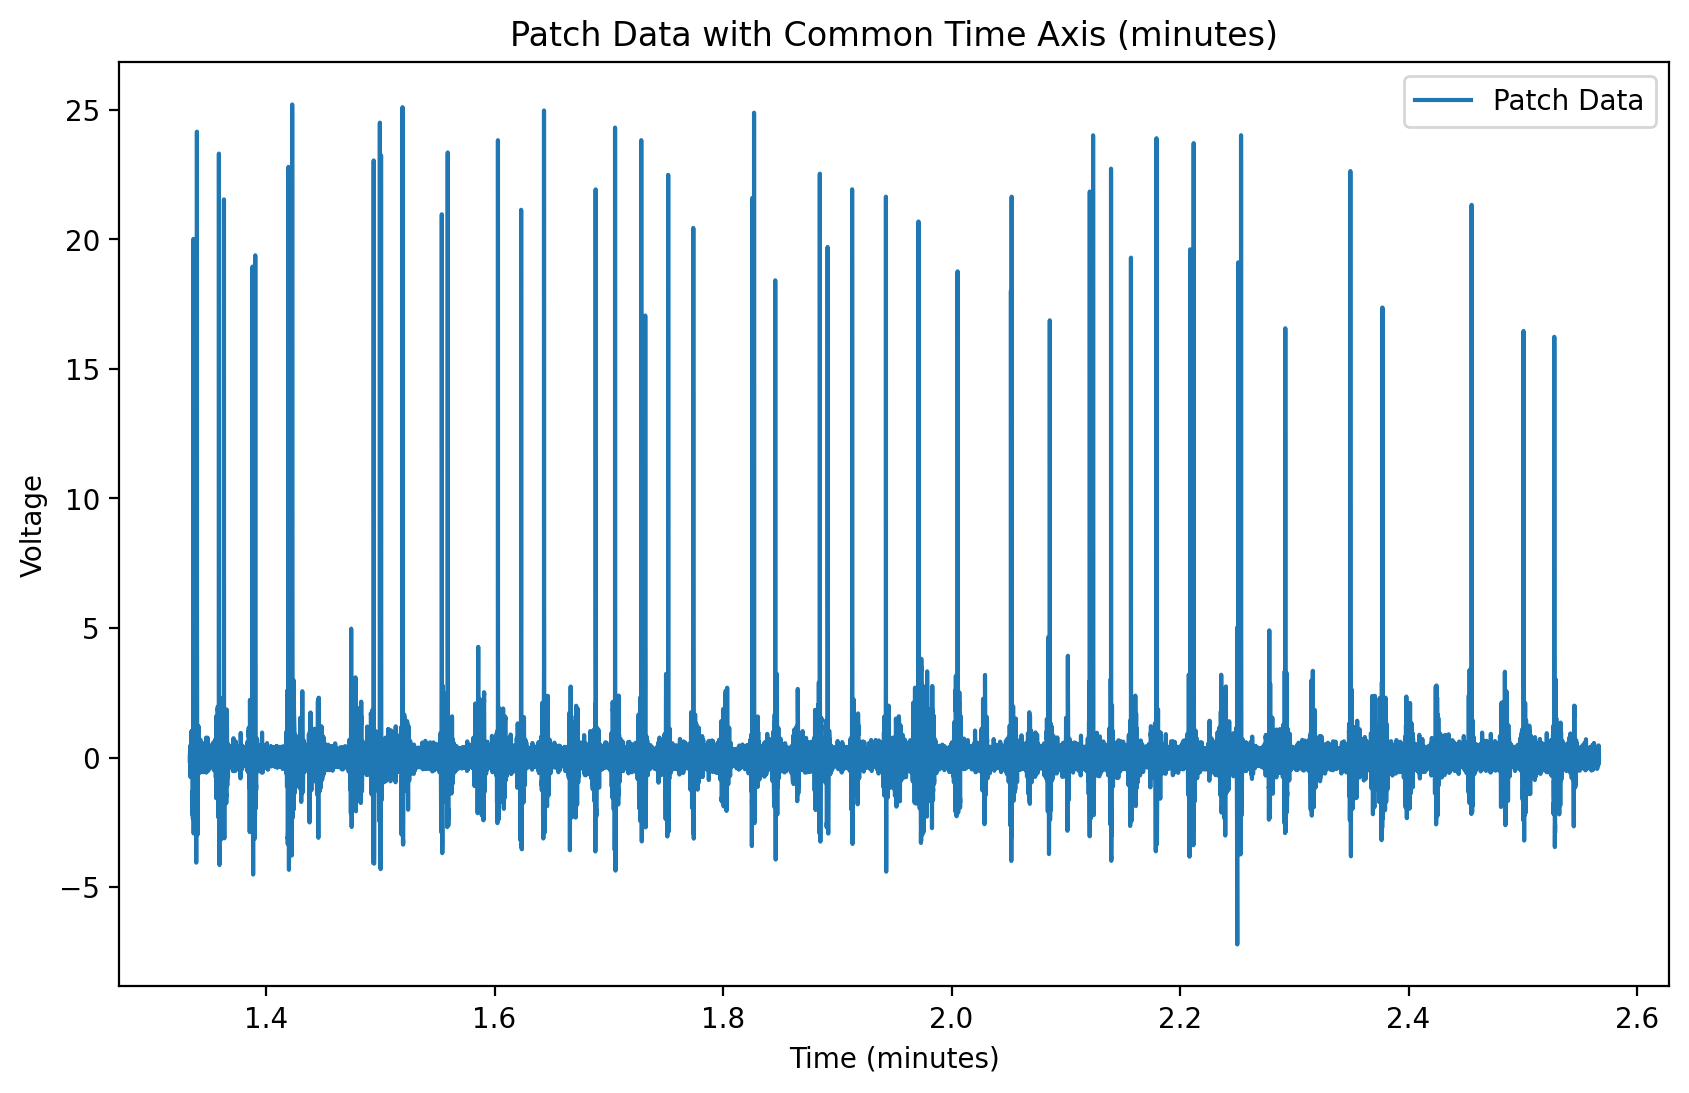

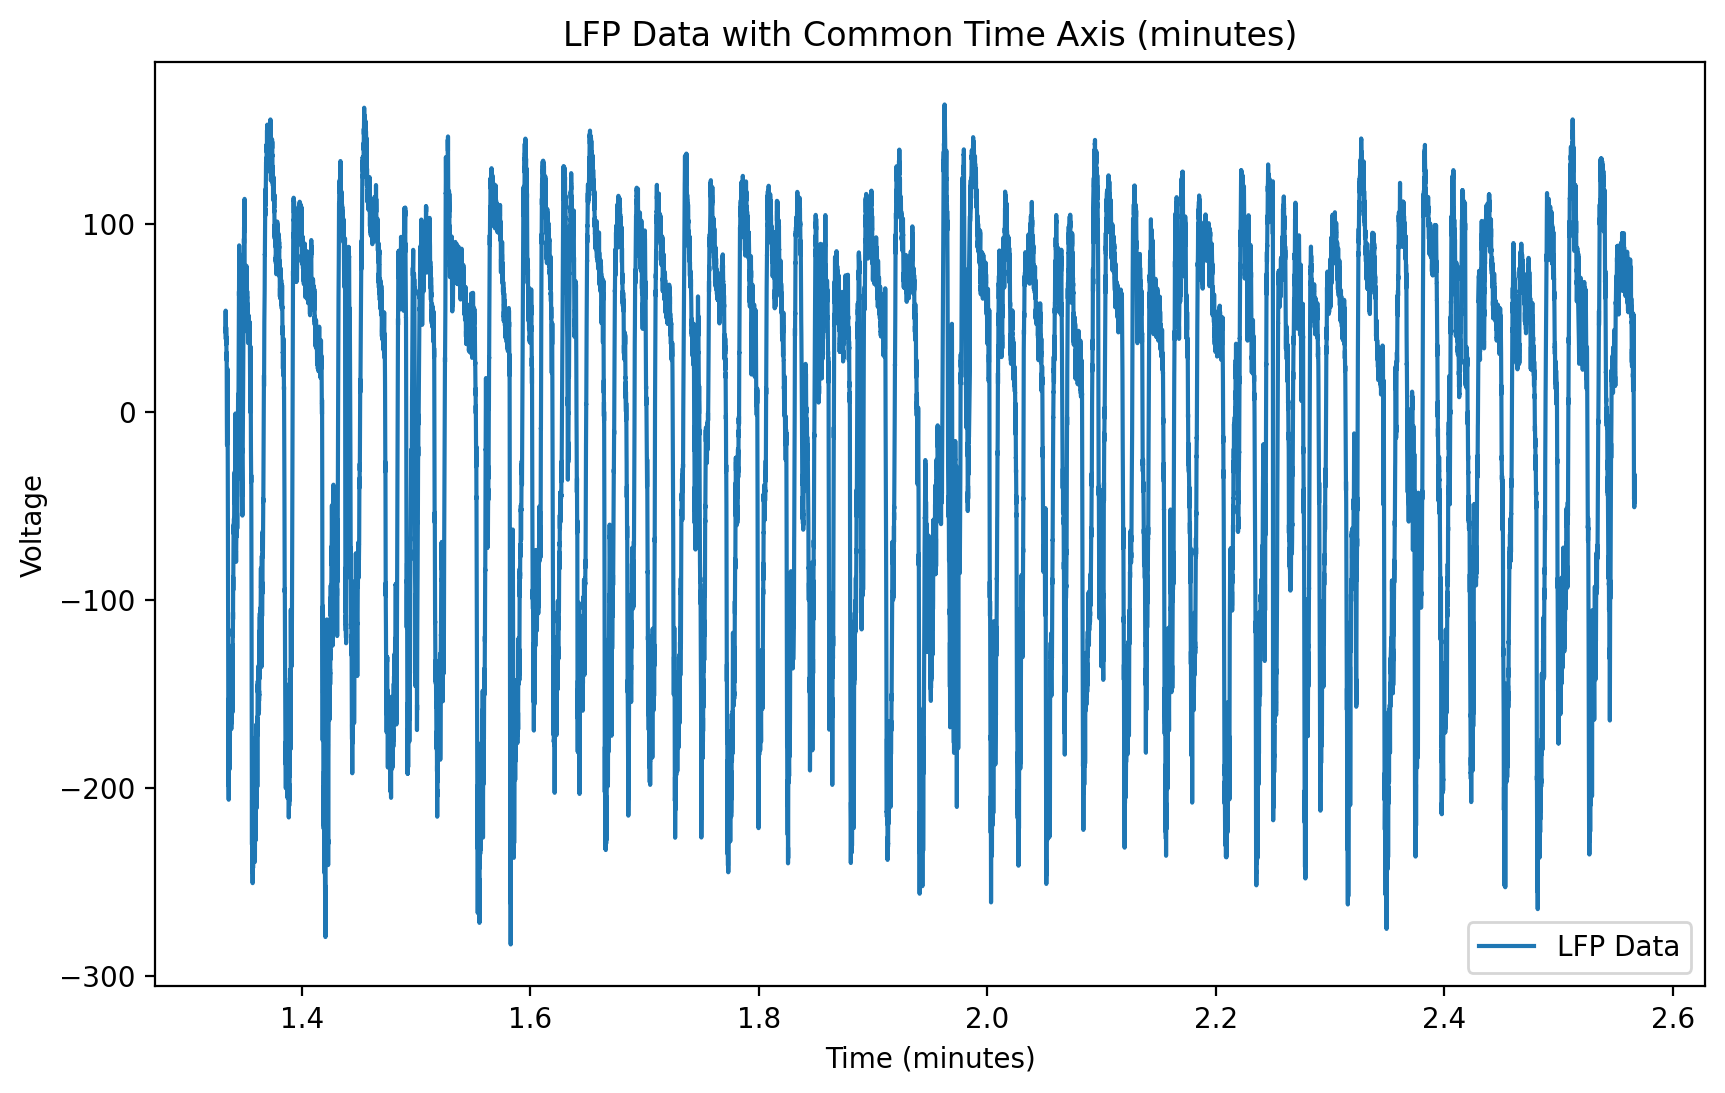

In [6]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: ANALYZE LFP DATA BY WINDOWS

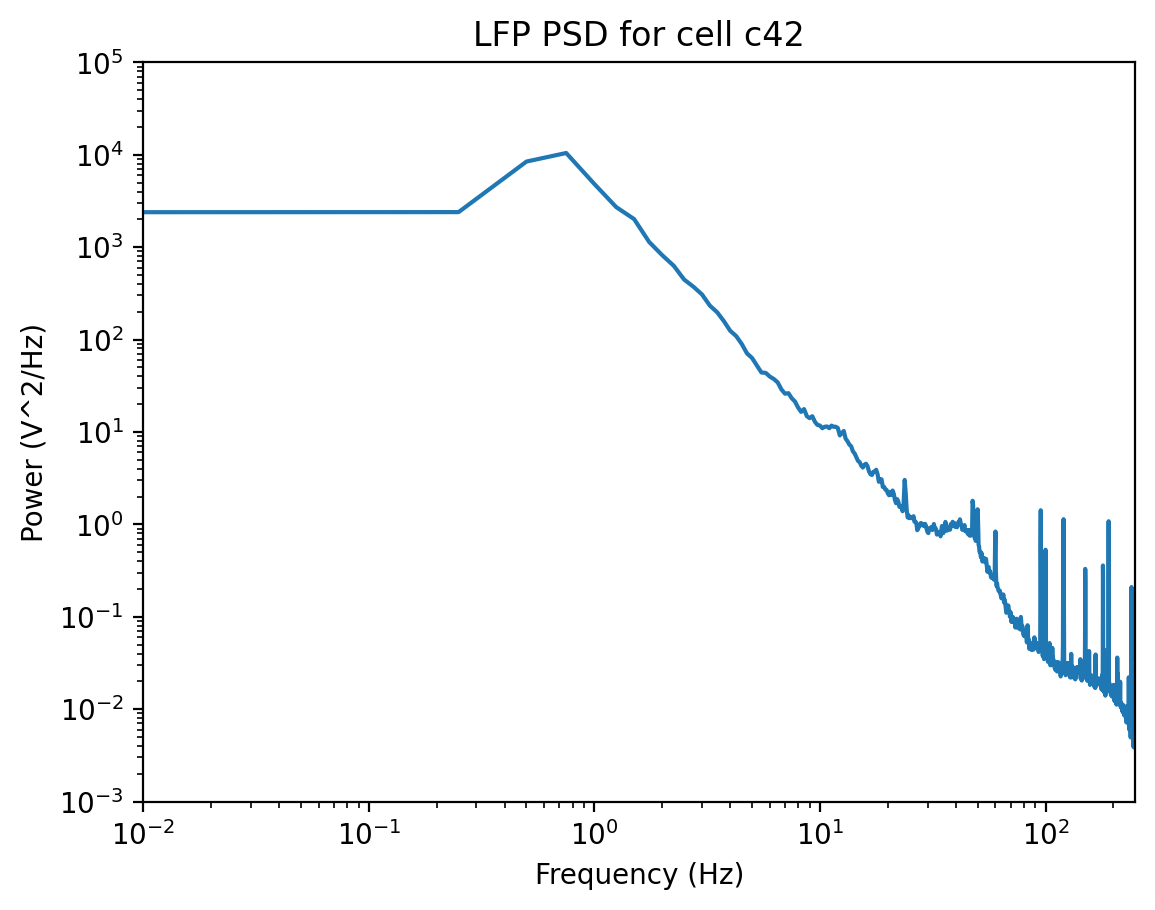

In [7]:
# plot power spectrum
fxx, pxx = spectral.compute_spectrum(lfp_filt, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx, pxx)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


In [8]:
bands = Bands({'gamma' : [30, 55]})

In [9]:
decim_factor = 10

###### SLIDING WINDOWS APPROACH - Welch

In [10]:
model_welch, freqs_welch, window_times_welch = compute_lfp_windows(
    lfp_signal=lfp_filt,
    fs=lfp_fs,
    method="welch", 
    decim_factor = decim_factor
)
summary_df_welch = model_welch.to_df()

Running group fits.:   0%|                    | 19/4041 [00:01<03:24, 19.68it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Running group fits.: 100%|█████████████████| 4041/4041 [00:25<00:00, 156.51it/s]


In [11]:
# Existing summary from specparam (offset, exponent, r_squared, error, n_peaks, etc.)
summary_df_welch = model_welch.to_df().reset_index(drop=True)

# + Add your band features (theta/alpha/beta/gamma _peak_power/_peak_cf/_peak_bw)
band_df = pd.DataFrame(
    [extract_peak_features(model_welch.get_model(i), max_peaks=4)
     for i in range(model_welch.n_time_windows)]
)

# Concatenate side-by-side
summary_df_welch = pd.concat([summary_df_welch, band_df], axis=1)

Fitting model across 4041 power spectra.
                                                                                                  
                                           TIME RESULTS                                           
                                                                                                  
                                 Number of time windows fit: 4041                                 
                                                                                                  
                        The model was run on the frequency range 1 - 90 Hz                        
                                 Frequency Resolution is 0.50 Hz                                  
                                                                                                  
                              Power spectra were fit without a knee.                              
                                                                    

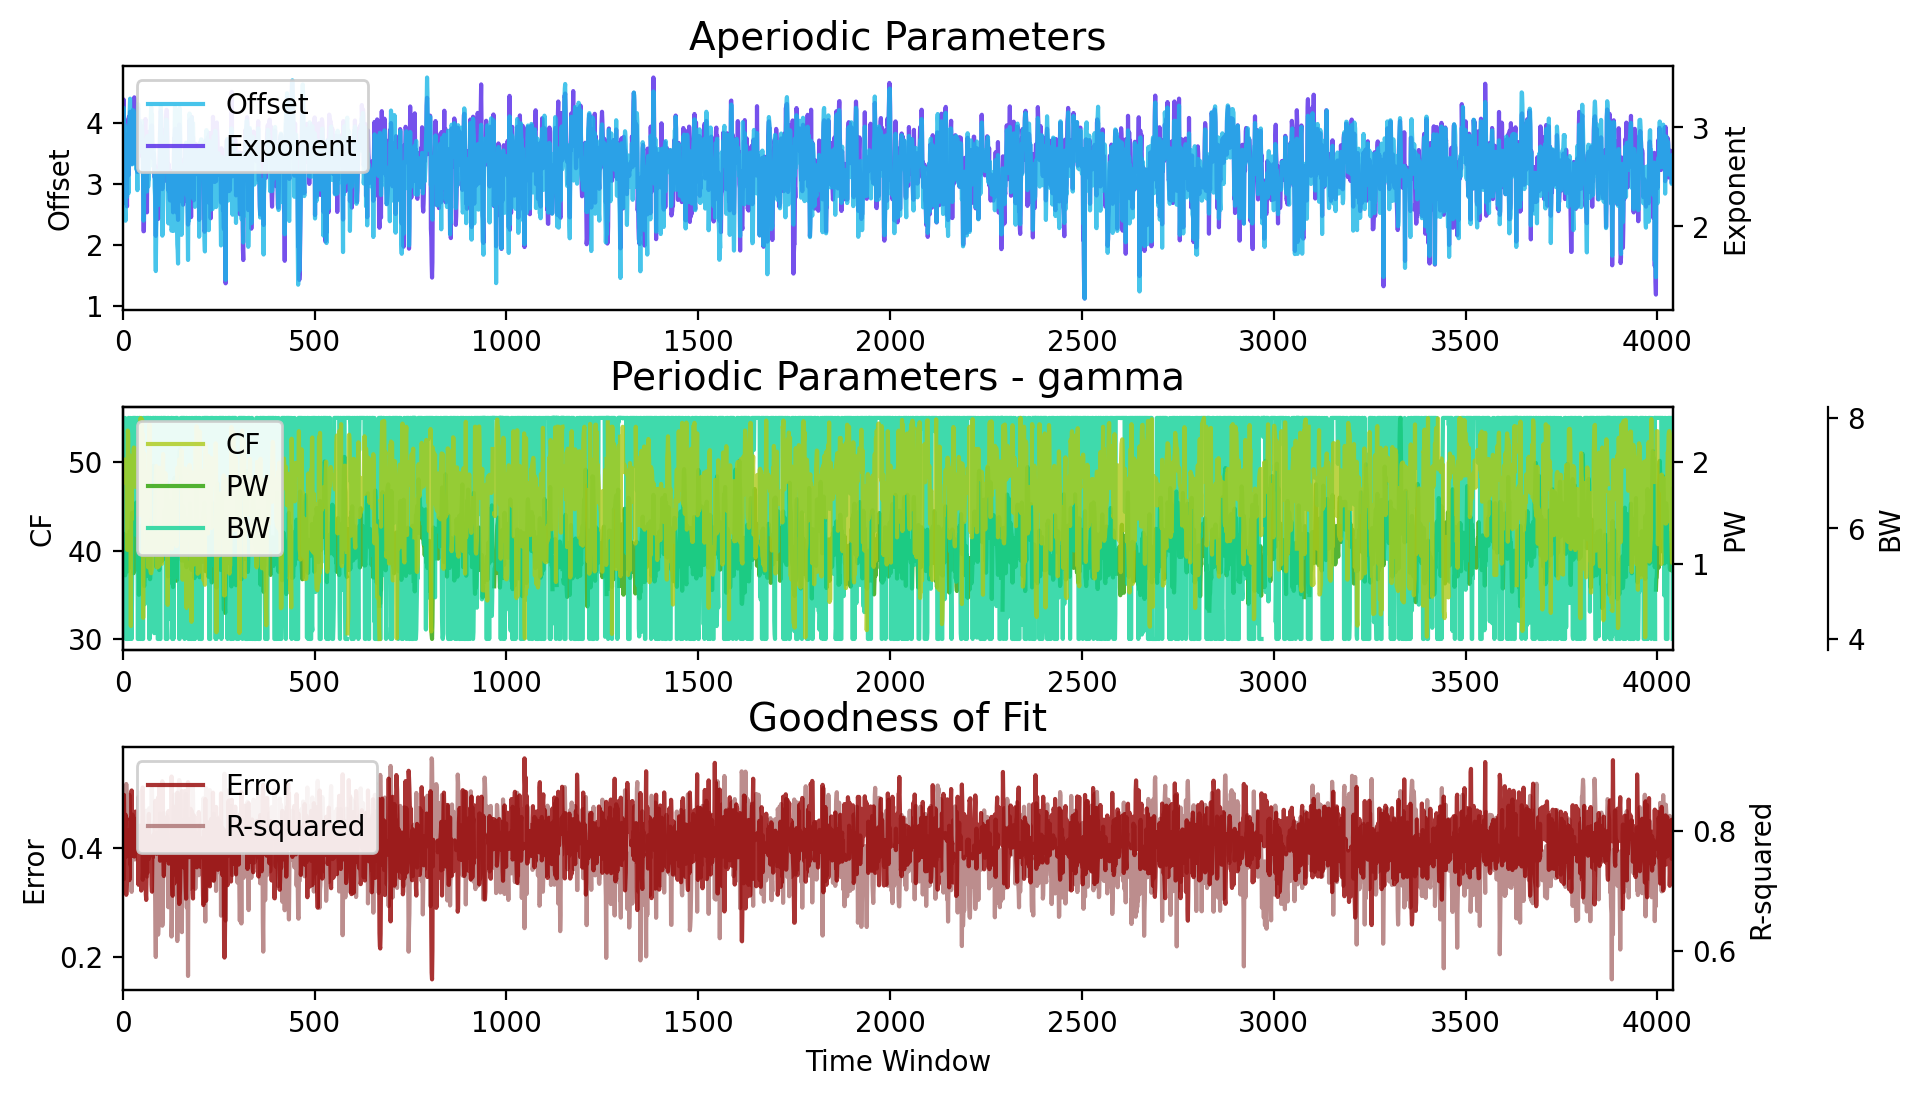

In [12]:
model_welch.report(peak_org=bands)

###### SLIDING WINDOWS APPROACH - Multitaper

In [13]:
model_mt, freqs_mt, window_times_mt = compute_lfp_windows(
    lfp_signal=lfp_filt,
    fs=lfp_fs,
    method="multitaper",
    decim_factor = decim_factor
)

summary_df_multitaper = model_mt.to_df()

Running group fits.: 100%|█████████████████| 4051/4051 [00:39<00:00, 102.14it/s]


Fitting model across 4051 power spectra.
                                                                                                  
                                           TIME RESULTS                                           
                                                                                                  
                                 Number of time windows fit: 4051                                 
                                                                                                  
                        The model was run on the frequency range 1 - 90 Hz                        
                                 Frequency Resolution is 0.35 Hz                                  
                                                                                                  
                              Power spectra were fit without a knee.                              
                                                                    

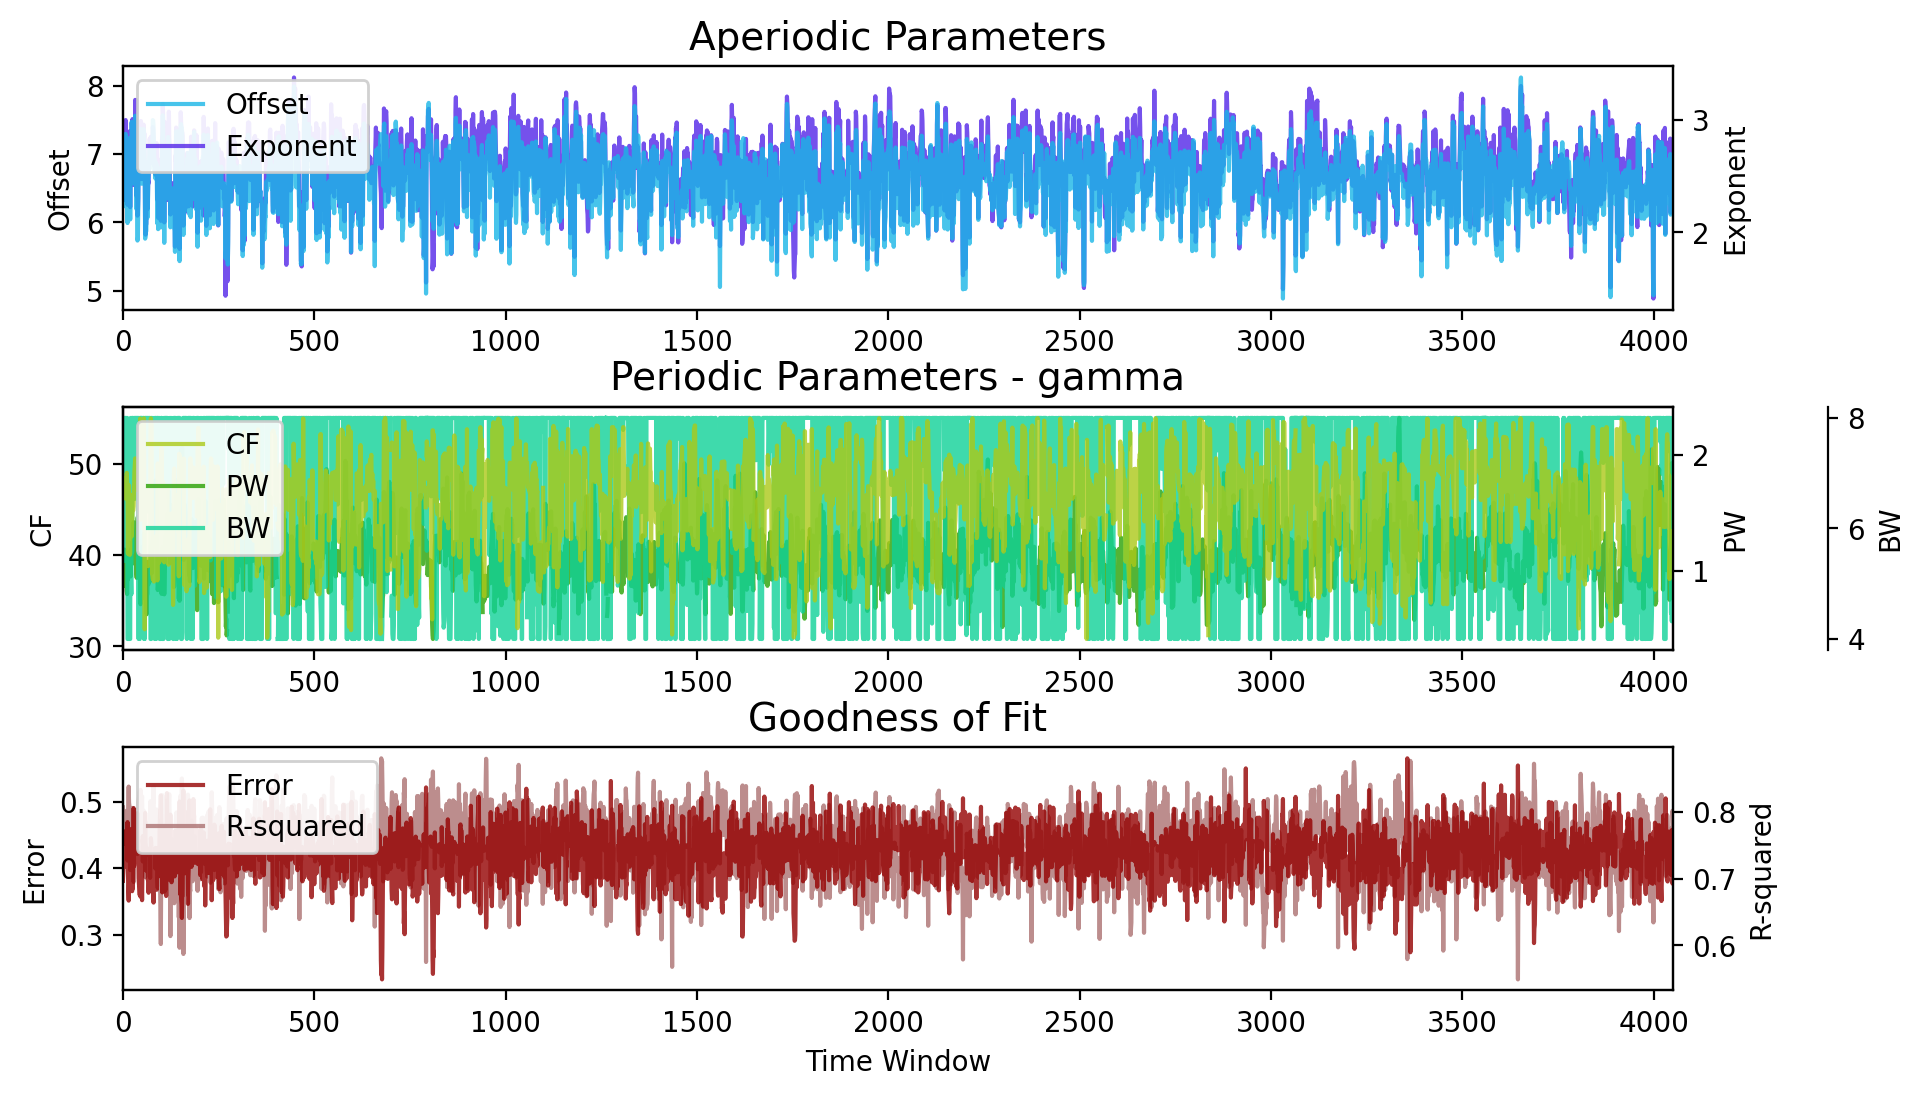

In [14]:
model_mt.report(peak_org=bands)

In [15]:
# Existing summary from specparam (offset, exponent, r_squared, error, n_peaks, etc.)
summary_df_multitaper = model_mt.to_df().reset_index(drop=True)

# + Add your band features (theta/alpha/beta/gamma _peak_power/_peak_cf/_peak_bw)
band_df = pd.DataFrame(
    [extract_peak_features(model_mt.get_model(i), max_peaks=4)
     for i in range(model_mt.n_time_windows)]
)

# Concatenate side-by-side
summary_df_multitaper = pd.concat([summary_df_multitaper, band_df], axis=1)


## STEP 2: Detect spikes from patch data

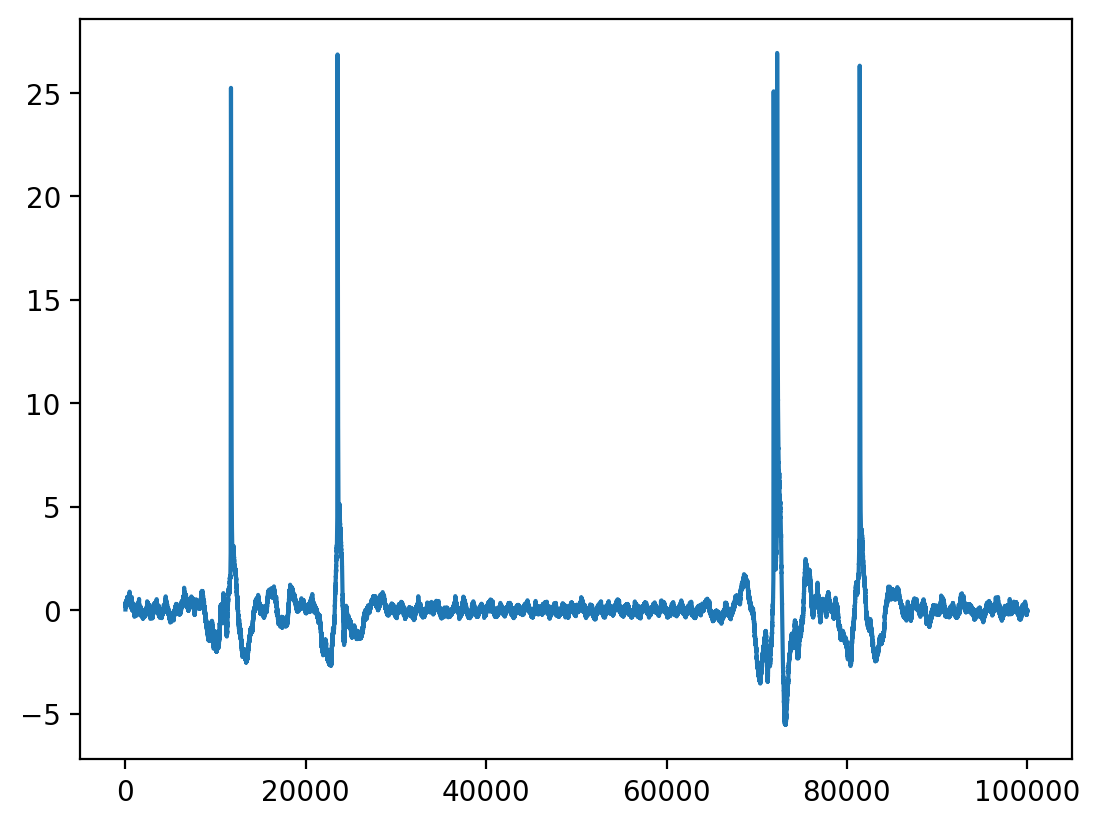

In [16]:
plt.plot(patch_filt[:100000] )

In [17]:



#threshold in mVs
sp = Spike(thresh_amp=spk_thresh, window_length=(5., 5.), smooth_frac=.01)

In [18]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/1418 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


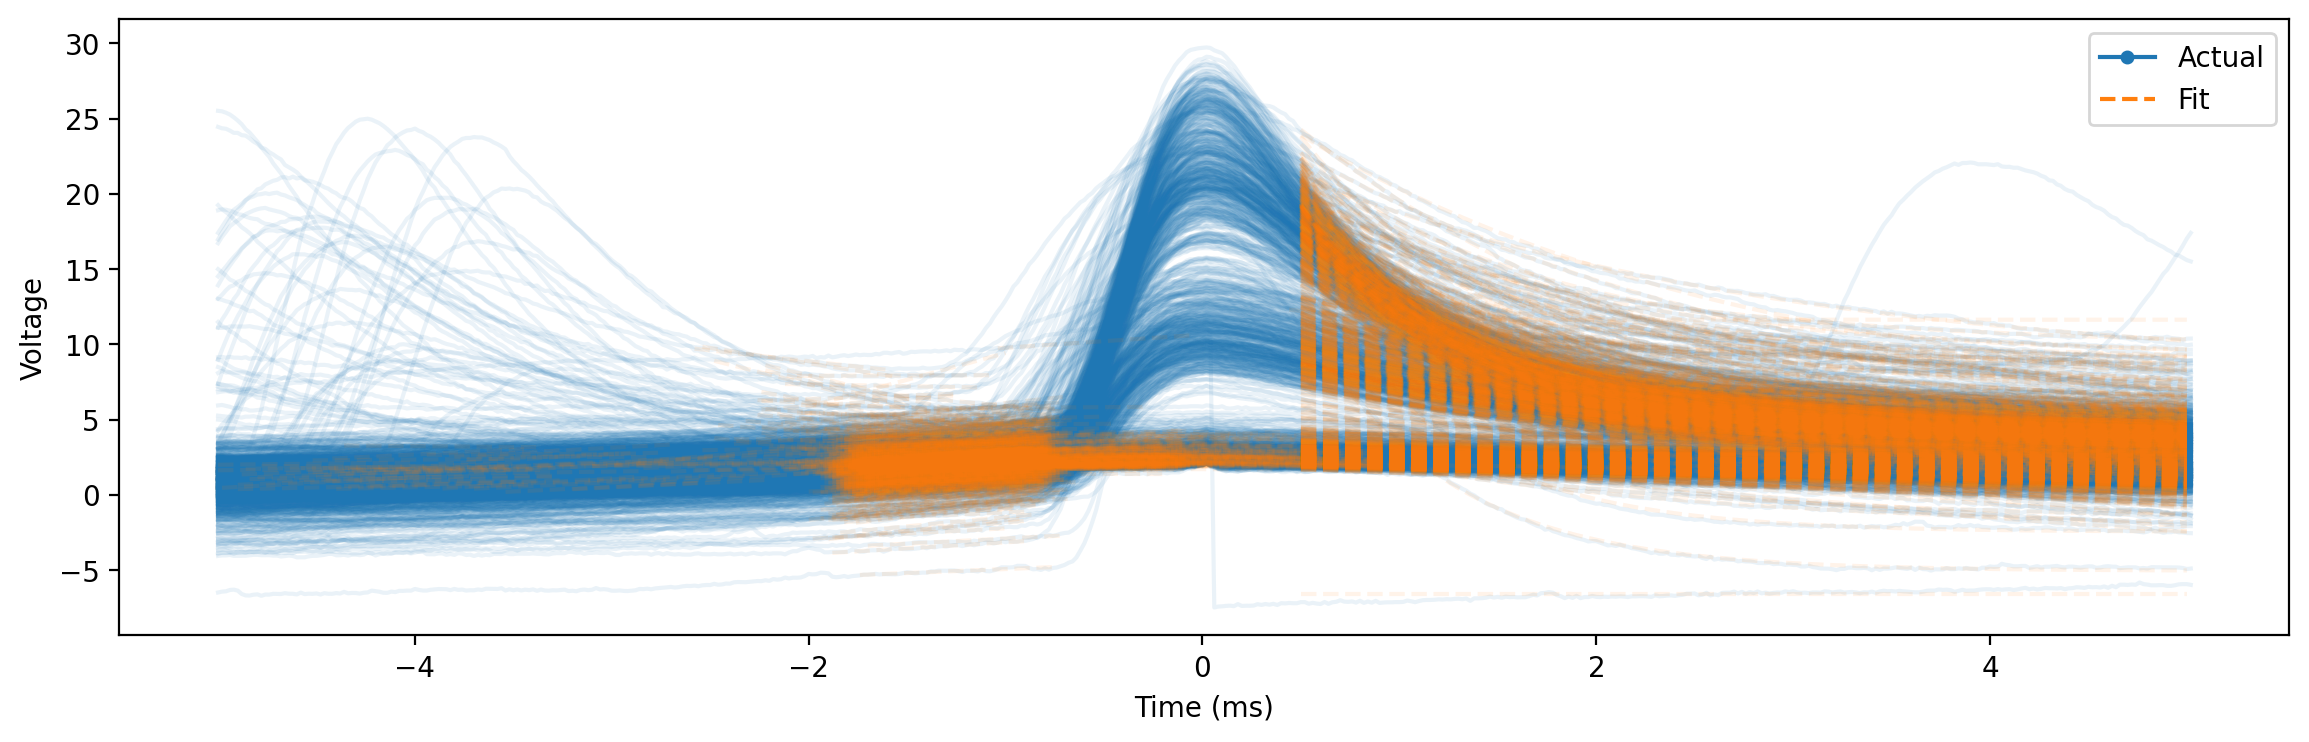

In [19]:
sp.plot()

### Filter spikes 

In [20]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [21]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [22]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,2.373367,11705,233.988239,0
1,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,2.988771,23523,470.235400,1
2,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,1.798995,72270,1444.709957,2
4,1.131318,0.72,3.423346,26.219775,1.14,0.626201,1.488794,3.536553,3.134033,81424,1627.702554,3
5,1.095346,0.72,3.602710,27.026259,1.20,0.577308,1.179299,3.795708,2.170699,149534,2989.252231,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1412,0.419223,0.74,1.372701,8.222671,2.70,0.136387,0.618987,3.460899,2.244713,40208636,803788.803062,984
1413,0.519763,0.74,2.010334,8.162258,2.22,0.076964,0.727547,3.676848,3.227047,40217424,803964.479153,985
1414,0.408720,0.70,2.936752,9.357549,2.00,0.152990,0.277083,1.381203,2.271959,40301801,805651.213512,986
1415,0.128864,0.76,1.236059,7.619188,1.88,0.090531,0.617930,2.007826,3.543086,40311158,805838.264170,987


### Get spike times


In [23]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 3: Align spikes to lfp windows

In [24]:
spike_to_window_map = map_spikes_to_windows(spk_times_ms, spk_ids, window_times_welch, df_features['spk_id'], lfp_fs)


### Visualize spikes and lfp windows 

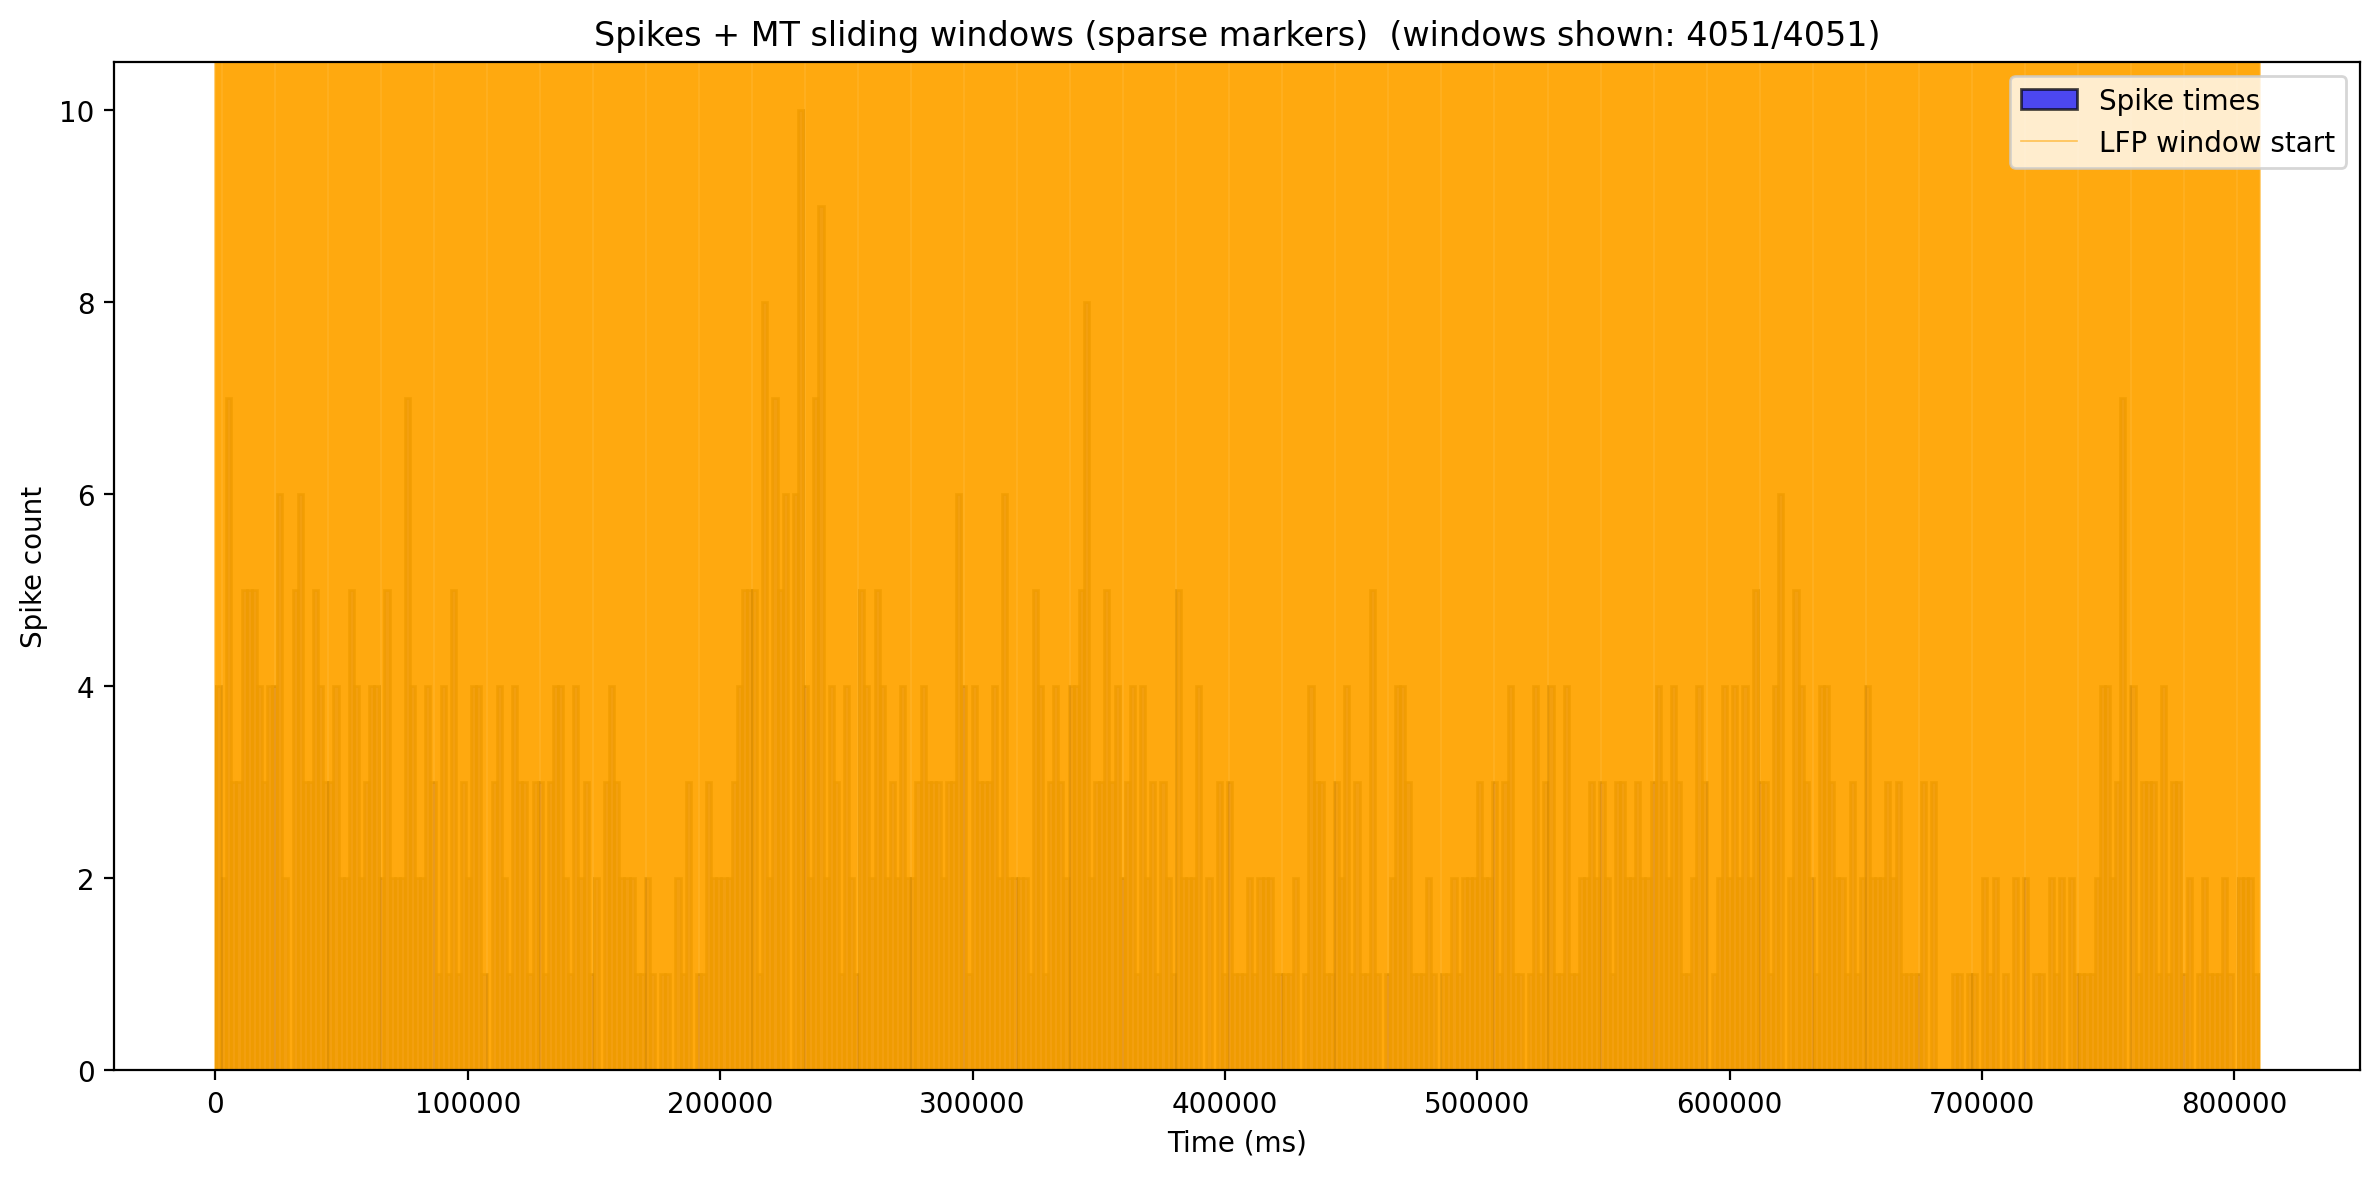

In [25]:
# full recording with very sparse window markers:
plot_spike_time_histogram_with_windows(
    spk_times_ms, window_times_mt, lfp_fs,
    bins=400, mode="lines", stride=0,
    title="Spikes + MT sliding windows (sparse markers)"
)


## STEP 4: COMBINE SPIKE DATAFRAME WITH LFP FEATURES (FOR CURRENT WINDOW AND PREVIOUS WINDOW)

In [26]:

df_combined_spk_lfp_welch = combine_spike_lfp_features(
    spike_data=df_features,
    summary_df=summary_df_welch,
    spike_to_window_map=spike_to_window_map
)
    
df_combined_spk_lfp_multit = combine_spike_lfp_features(
    spike_data=df_features,
    summary_df=summary_df_multitaper, 
    spike_to_window_map=spike_to_window_map
)

In [27]:
df_combined_spk_lfp_multit[:3000]

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,...,lfp_previous_theta_peak_bw,lfp_previous_alpha_peak_power,lfp_previous_alpha_peak_cf,lfp_previous_alpha_peak_bw,lfp_previous_beta_peak_power,lfp_previous_beta_peak_cf,lfp_previous_beta_peak_bw,lfp_previous_gamma_peak_power,lfp_previous_gamma_peak_cf,lfp_previous_gamma_peak_bw
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,2.373367,11705,...,"[None, nan]","[None, nan]","[None, nan]","[None, nan]","[None, nan]","[None, nan]","[None, nan]","[None, 0.730432277855521]","[None, 43.63968543565943]","[None, 5.999990588821369]"
1,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,2.988771,23523,...,"[None, nan, nan]","[None, nan, nan]","[None, nan, nan]","[None, nan, nan]","[None, nan, nan]","[None, nan, nan]","[None, nan, nan]","[None, 0.730432277855521, 0.7908483949817964]","[None, 43.63968543565943, 44.103110264160705]","[None, 5.999990588821369, 5.999999999280639]"
2,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,1.798995,72270,...,"[None, nan, nan, nan, nan, 7.999999989826406, ...","[None, nan, nan, nan, nan, nan, nan, nan]","[None, nan, nan, nan, nan, nan, nan, nan]","[None, nan, nan, nan, nan, nan, nan, nan]","[None, nan, nan, nan, nan, nan, nan, 0.5570061...","[None, nan, nan, nan, nan, nan, nan, 25.977215...","[None, nan, nan, nan, nan, nan, nan, 7.9999999...","[None, 0.730432277855521, 0.7908483949817964, ...","[None, 43.63968543565943, 44.103110264160705, ...","[None, 5.999990588821369, 5.999999999280639, 6..."
4,1.131318,0.72,3.423346,26.219775,1.14,0.626201,1.488794,3.536553,3.134033,81424,...,"[None, nan, nan, nan, nan, 7.999999989826406, ...","[None, nan, nan, nan, nan, nan, nan, nan, nan]","[None, nan, nan, nan, nan, nan, nan, nan, nan]","[None, nan, nan, nan, nan, nan, nan, nan, nan]","[None, nan, nan, nan, nan, nan, nan, 0.5570061...","[None, nan, nan, nan, nan, nan, nan, 25.977215...","[None, nan, nan, nan, nan, nan, nan, 7.9999999...","[None, 0.730432277855521, 0.7908483949817964, ...","[None, 43.63968543565943, 44.103110264160705, ...","[None, 5.999990588821369, 5.999999999280639, 6..."
5,1.095346,0.72,3.602710,27.026259,1.20,0.577308,1.179299,3.795708,2.170699,149534,...,"[7.999999989826406, nan, nan, nan, nan, nan, n...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, 0.5570061841365472, nan, nan, nan, ...","[nan, nan, 25.977215679580617, nan, nan, nan, ...","[nan, nan, 7.999999999999999, nan, nan, nan, 7...","[0.9339079272757218, 0.8901223900288209, 0.987...","[43.62906770630067, 44.0502975075107, 46.18993...","[4.706137720198017, 5.9999970926880675, 7.9999..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1412,0.419223,0.74,1.372701,8.222671,2.70,0.136387,0.618987,3.460899,2.244713,40208636,...,"[7.999999999999999, nan, nan, nan, nan, nan, n...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, 0.386...","[nan, nan, nan, nan, nan, nan, nan, nan, 29.90...","[nan, nan, nan, nan, nan, nan, nan, nan, 7.999...","[1.1240612962117842, 1.8451141757773168, 1.397...","[46.88871022261483, 41.71183683747151, 46.9408...","[6.0, 7.999999793306976, 5.999999971581268, 5...."
1413,0.519763,0.74,2.010334,8.162258,2.22,0.076964,0.727547,3.676848,3.227047,40217424,...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, 0.38615863...","[nan, nan, nan, nan, nan, nan, nan, 29.9019614...","[nan, nan, nan, nan, nan, nan, nan, 7.99999999...","[1.8451141757773168, 1.3977640

### STEP 5: ANALYZE IF SPIKE WAVEFORM FEATURES CHANGE BASED ON CURRENT AND PREVIOUS LFP WINDOW - CORRELATIONS

In [28]:
# Define spike and LFP features
spike_features = ['ramp_amp', 'inflection_time', 'inflection_amp','peak_amp', 'peak_width', 'peak_sharpness','exp_lambda', 	'exp_const', 'log_isi']
freq_bands = [ 'gamma']
# Periodic features for mean correlation analysis
peak_features = (
    [f"lfp_current_{i}_peak_cf_mean" for i in freq_bands] +
    [f"lfp_current_{i}_peak_power_mean" for i in freq_bands] +
    [f"lfp_current_{i}_peak_bw_mean" for i in freq_bands]
)



lfp_features_current_mean = [
    'lfp_current_offset_mean',
    'lfp_current_exponent_mean',
    'lfp_current_r_squared_mean',
    'lfp_current_n_peaks_mean'
] + peak_features

# Same for previous if needed
peak_features_prev = (
    [f"lfp_previous_{i}_peak_cf_mean" for i in freq_bands] +
    [f"lfp_previous_{i}_peak_power_mean" for i in freq_bands] +
    [f"lfp_previous_{i}_peak_bw_mean" for i in freq_bands]
)

lfp_features_previous_mean = [
    'lfp_previous_offset_mean',
    'lfp_previous_exponent_mean',
    'lfp_previous_r_squared_mean',
    'lfp_previous_n_peaks_mean'
] + peak_features_prev


In [29]:


df_current_lfp_processed_welch = compute_lfp_feature_means(
    df=df_combined_spk_lfp_welch,
    lfp_type="current",
    drop_irrelevant=True,  # Drop previous LFP features
    drop_original=True,    # Drop original current LFP list columns
)
df_previous_lfp_processed_welch = compute_lfp_feature_means(
    df=df_combined_spk_lfp_welch,
    lfp_type="previous",
    drop_irrelevant=True,  # Drop current LFP features
    drop_original=True,    # Drop original previous LFP list columns
)

df_current_lfp_processed_multit = compute_lfp_feature_means(
    df=df_combined_spk_lfp_multit,
    lfp_type="current",
    drop_irrelevant=True,  # Drop previous LFP features
    drop_original=True,    # Drop original current LFP list columns
)
df_previous_lfp_processed_multit = compute_lfp_feature_means(
    df=df_combined_spk_lfp_multit,
    lfp_type="previous",
    drop_irrelevant=True,  # Drop current LFP features
    drop_original=True,    # Drop original previous LFP list columns
)

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/lfp_spike_window_analysis.py:285: RuntimeWarning: Mean of empty slice
  np.nanmean([v for v in x if v is not None])
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/lfp_spike_window_analysis.py:285: RuntimeWarning: Mean of empty slice
  np.nanmean([v for v in x if v is not None])
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/lfp_spike_window_analysis.py:285: RuntimeWarning: Mean of empty slice
  np.nanmean([v for v in x if v is not None])
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/lfp_spike_window_analysis.py:285: RuntimeWarning: Mean of empty slice
  np.nanmean([v for v in x if v is not None])
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/lfp_spike_window_analysis.py:285: Ru

In [30]:
df_current_lfp_processed_multit

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,...,lfp_current_theta_peak_bw_mean,lfp_current_alpha_peak_power_mean,lfp_current_alpha_peak_cf_mean,lfp_current_alpha_peak_bw_mean,lfp_current_beta_peak_power_mean,lfp_current_beta_peak_cf_mean,lfp_current_beta_peak_bw_mean,lfp_current_gamma_peak_power_mean,lfp_current_gamma_peak_cf_mean,lfp_current_gamma_peak_bw_mean
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,2.373367,11705,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.760640,43.871398,5.999995
1,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,2.988771,23523,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.807350,44.105143,5.999997
2,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,1.798995,72270,...,8.0,NaN,NaN,NaN,0.557006,25.977216,8.000000,0.884196,44.718981,6.338266
4,1.131318,0.72,3.423346,26.219775,1.14,0.626201,1.488794,3.536553,3.134033,81424,...,8.0,NaN,NaN,NaN,0.557006,25.977216,8.000000,0.892588,44.264700,6.249428
5,1.095346,0.72,3.602710,27.026259,1.20,0.577308,1.179299,3.795708,2.170699,149534,...,7.0,NaN,NaN,NaN,0.731187,21.720513,8.000000,0.918868,45.097556,6.161074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1412,0.419223,0.74,1.372701,8.222671,2.70,0.136387,0.618987,3.460899,2.244713,40208636,...,NaN,NaN,NaN,NaN,0.386159,29.901961,8.000000,1.288693,45.419397,6.620818
1413,0.519763,0.74,2.010334,8.162258,2.22,0.076964,0.727547,3.676848,3.227047,40217424,...,NaN,NaN,NaN,NaN,0.386159,29.901961,8.000000,1.228083,46.222369,6.420818
1414,0.408720,0.70,2.936752,9.357549,2.00,0.152990,0.277083,1.381203,2.271959,40301801,...,NaN,NaN,NaN,NaN,0.627750,23.162018,7.200000,1.217855,48.108246,6.377258
1415,0.128864,0.76,1.236059,7.619188,1.88,0.090531,0.617930,2.007826,3.543086,40311158,...,NaN,NaN,NaN,NaN,0.612982,23.722133,7.333333,1.243331,47.855170,6.282672


In [31]:
df_current_lfp_processed_multit = compute_lfp_feature_means(
    df=df_combined_spk_lfp_multit,
    lfp_type="current",
    drop_irrelevant=True,  # Drop previous LFP features
    drop_original=True,    # Drop original current LFP list columns
)
df_previous_lfp_processed_multit = compute_lfp_feature_means(
    df=df_combined_spk_lfp_multit,
    lfp_type="previous",
    drop_irrelevant=True,  # Drop current LFP features
    drop_original=True,    # Drop original previous LFP list columns
)

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/lfp_spike_window_analysis.py:285: RuntimeWarning: Mean of empty slice
  np.nanmean([v for v in x if v is not None])
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/lfp_spike_window_analysis.py:285: RuntimeWarning: Mean of empty slice
  np.nanmean([v for v in x if v is not None])
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/lfp_spike_window_analysis.py:285: RuntimeWarning: Mean of empty slice
  np.nanmean([v for v in x if v is not None])
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/lfp_spike_window_analysis.py:285: RuntimeWarning: Mean of empty slice
  np.nanmean([v for v in x if v is not None])
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/lfp_spike_window_analysis.py:285: Ru

In [32]:
columns_to_drop = [
    'lfp_current_r_squared_mean',
    'lfp_current_n_peaks_mean',
    'lfp_current_theta_peak_power_mean',
    'lfp_current_theta_peak_cf_mean',
    'lfp_current_theta_peak_bw_mean',
    'lfp_current_alpha_peak_power_mean',
    'lfp_current_alpha_peak_cf_mean',
    'lfp_current_alpha_peak_bw_mean',
    'lfp_current_beta_peak_power_mean',
    'lfp_current_beta_peak_bw_mean',
    'lfp_current_beta_peak_cf_mean', 'spk_times_idx', 	'spk_times_ms', 	'spk_id', 'log_isi'
]

df_current_lfp_processed_multit.drop(columns=columns_to_drop, inplace=True, errors='ignore')


In [33]:
df_current_lfp_processed_multit

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,lfp_current_offset_mean,lfp_current_exponent_mean,lfp_current_error_mean,lfp_current_gamma_peak_power_mean,lfp_current_gamma_peak_cf_mean,lfp_current_gamma_peak_bw_mean
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,6.339220,2.366572,0.388793,0.760640,43.871398,5.999995
1,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,6.304204,2.340195,0.398069,0.807350,44.105143,5.999997
2,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,6.648273,2.567236,0.412015,0.884196,44.718981,6.338266
4,1.131318,0.72,3.423346,26.219775,1.14,0.626201,1.488794,3.536553,6.696044,2.601454,0.416973,0.892588,44.264700,6.249428
5,1.095346,0.72,3.602710,27.026259,1.20,0.577308,1.179299,3.795708,6.750351,2.643079,0.429596,0.918868,45.097556,6.161074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1412,0.419223,0.74,1.372701,8.222671,2.70,0.136387,0.618987,3.460899,6.854023,2.631433,0.401909,1.288693,45.419397,6.620818
1413,0.519763,0.74,2.010334,8.162258,2.22,0.076964,0.727547,3.676848,6.901053,2.653732,0.394153,1.228083,46.222369,6.420818
1414,0.408720,0.70,2.936752,9.357549,2.00,0.152990,0.277083,1.381203,6.861948,2.697144,0.413750,1.217855,48.108246,6.377258
1415,0.128864,0.76,1.236059,7.619188,1.88,0.090531,0.617930,2.007826,6.854182,2.709771,0.422041,1.243331,47.855170,6.282672


In [34]:
lfp_features_previous_mean

['lfp_previous_offset_mean',
 'lfp_previous_exponent_mean',
 'lfp_previous_r_squared_mean',
 'lfp_previous_n_peaks_mean',
 'lfp_previous_gamma_peak_cf_mean',
 'lfp_previous_gamma_peak_power_mean',
 'lfp_previous_gamma_peak_bw_mean']

In [35]:
"""

plot_lfp_spk_correlation_heatmap(
    df_current_lfp_processed_welch,
    spike_features,
    lfp_features_current_mean, title = "Correlation heatmap Welch current LFP window")
plot_lfp_spk_correlation_heatmap(
    df_previous_lfp_processed_welch,
    spike_features,
    lfp_features_previous_mean, title = "Correlation heatmap Welch previous LFP window")""
"""


'\n\nplot_lfp_spk_correlation_heatmap(\n    df_current_lfp_processed_welch,\n    spike_features,\n    lfp_features_current_mean, title = "Correlation heatmap Welch current LFP window")\nplot_lfp_spk_correlation_heatmap(\n    df_previous_lfp_processed_welch,\n    spike_features,\n    lfp_features_previous_mean, title = "Correlation heatmap Welch previous LFP window")""\n'

In [36]:
lfp_features_current_mean

['lfp_current_offset_mean',
 'lfp_current_exponent_mean',
 'lfp_current_r_squared_mean',
 'lfp_current_n_peaks_mean',
 'lfp_current_gamma_peak_cf_mean',
 'lfp_current_gamma_peak_power_mean',
 'lfp_current_gamma_peak_bw_mean']

In [37]:
df_current_lfp_processed_multit


,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,lfp_current_offset_mean,lfp_current_exponent_mean,lfp_current_error_mean,lfp_current_gamma_peak_power_mean,lfp_current_gamma_peak_cf_mean,lfp_current_gamma_peak_bw_mean
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,6.339220,2.366572,0.388793,0.760640,43.871398,5.999995
1,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,6.304204,2.340195,0.398069,0.807350,44.105143,5.999997
2,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,6.648273,2.567236,0.412015,0.884196,44.718981,6.338266
4,1.131318,0.72,3.423346,26.219775,1.14,0.626201,1.488794,3.536553,6.696044,2.601454,0.416973,0.892588,44.264700,6.249428
5,1.095346,0.72,3.602710,27.026259,1.20,0.577308,1.179299,3.795708,6.750351,2.643079,0.429596,0.918868,45.097556,6.161074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1412,0.419223,0.74,1.372701,8.222671,2.70,0.136387,0.618987,3.460899,6.854023,2.631433,0.401909,1.288693,45.419397,6.620818
1413,0.519763,0.74,2.010334,8.162258,2.22,0.076964,0.727547,3.676848,6.901053,2.653732,0.394153,1.228083,46.222369,6.420818
1414,0.408720,0.70,2.936752,9.357549,2.00,0.152990,0.277083,1.381203,6.861948,2.697144,0.413750,1.217855,48.108246,6.377258
1415,0.128864,0.76,1.236059,7.619188,1.88,0.090531,0.617930,2.007826,6.854182,2.709771,0.422041,1.243331,47.855170,6.282672


In [38]:
df_current_lfp_processed_multit

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,lfp_current_offset_mean,lfp_current_exponent_mean,lfp_current_error_mean,lfp_current_gamma_peak_power_mean,lfp_current_gamma_peak_cf_mean,lfp_current_gamma_peak_bw_mean
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,6.339220,2.366572,0.388793,0.760640,43.871398,5.999995
1,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,6.304204,2.340195,0.398069,0.807350,44.105143,5.999997
2,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,6.648273,2.567236,0.412015,0.884196,44.718981,6.338266
4,1.131318,0.72,3.423346,26.219775,1.14,0.626201,1.488794,3.536553,6.696044,2.601454,0.416973,0.892588,44.264700,6.249428
5,1.095346,0.72,3.602710,27.026259,1.20,0.577308,1.179299,3.795708,6.750351,2.643079,0.429596,0.918868,45.097556,6.161074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1412,0.419223,0.74,1.372701,8.222671,2.70,0.136387,0.618987,3.460899,6.854023,2.631433,0.401909,1.288693,45.419397,6.620818
1413,0.519763,0.74,2.010334,8.162258,2.22,0.076964,0.727547,3.676848,6.901053,2.653732,0.394153,1.228083,46.222369,6.420818
1414,0.408720,0.70,2.936752,9.357549,2.00,0.152990,0.277083,1.381203,6.861948,2.697144,0.413750,1.217855,48.108246,6.377258
1415,0.128864,0.76,1.236059,7.619188,1.88,0.090531,0.617930,2.007826,6.854182,2.709771,0.422041,1.243331,47.855170,6.282672


In [39]:
[c for c in df_combined_spk_lfp_multit.columns if c.startswith("lfp_current_")]


['lfp_current_offset',
 'lfp_current_exponent',
 'lfp_current_r_squared',
 'lfp_current_error',
 'lfp_current_theta_peak_power',
 'lfp_current_theta_peak_cf',
 'lfp_current_theta_peak_bw',
 'lfp_current_alpha_peak_power',
 'lfp_current_alpha_peak_cf',
 'lfp_current_alpha_peak_bw',
 'lfp_current_beta_peak_power',
 'lfp_current_beta_peak_cf',
 'lfp_current_beta_peak_bw',
 'lfp_current_gamma_peak_power',
 'lfp_current_gamma_peak_cf',
 'lfp_current_gamma_peak_bw']

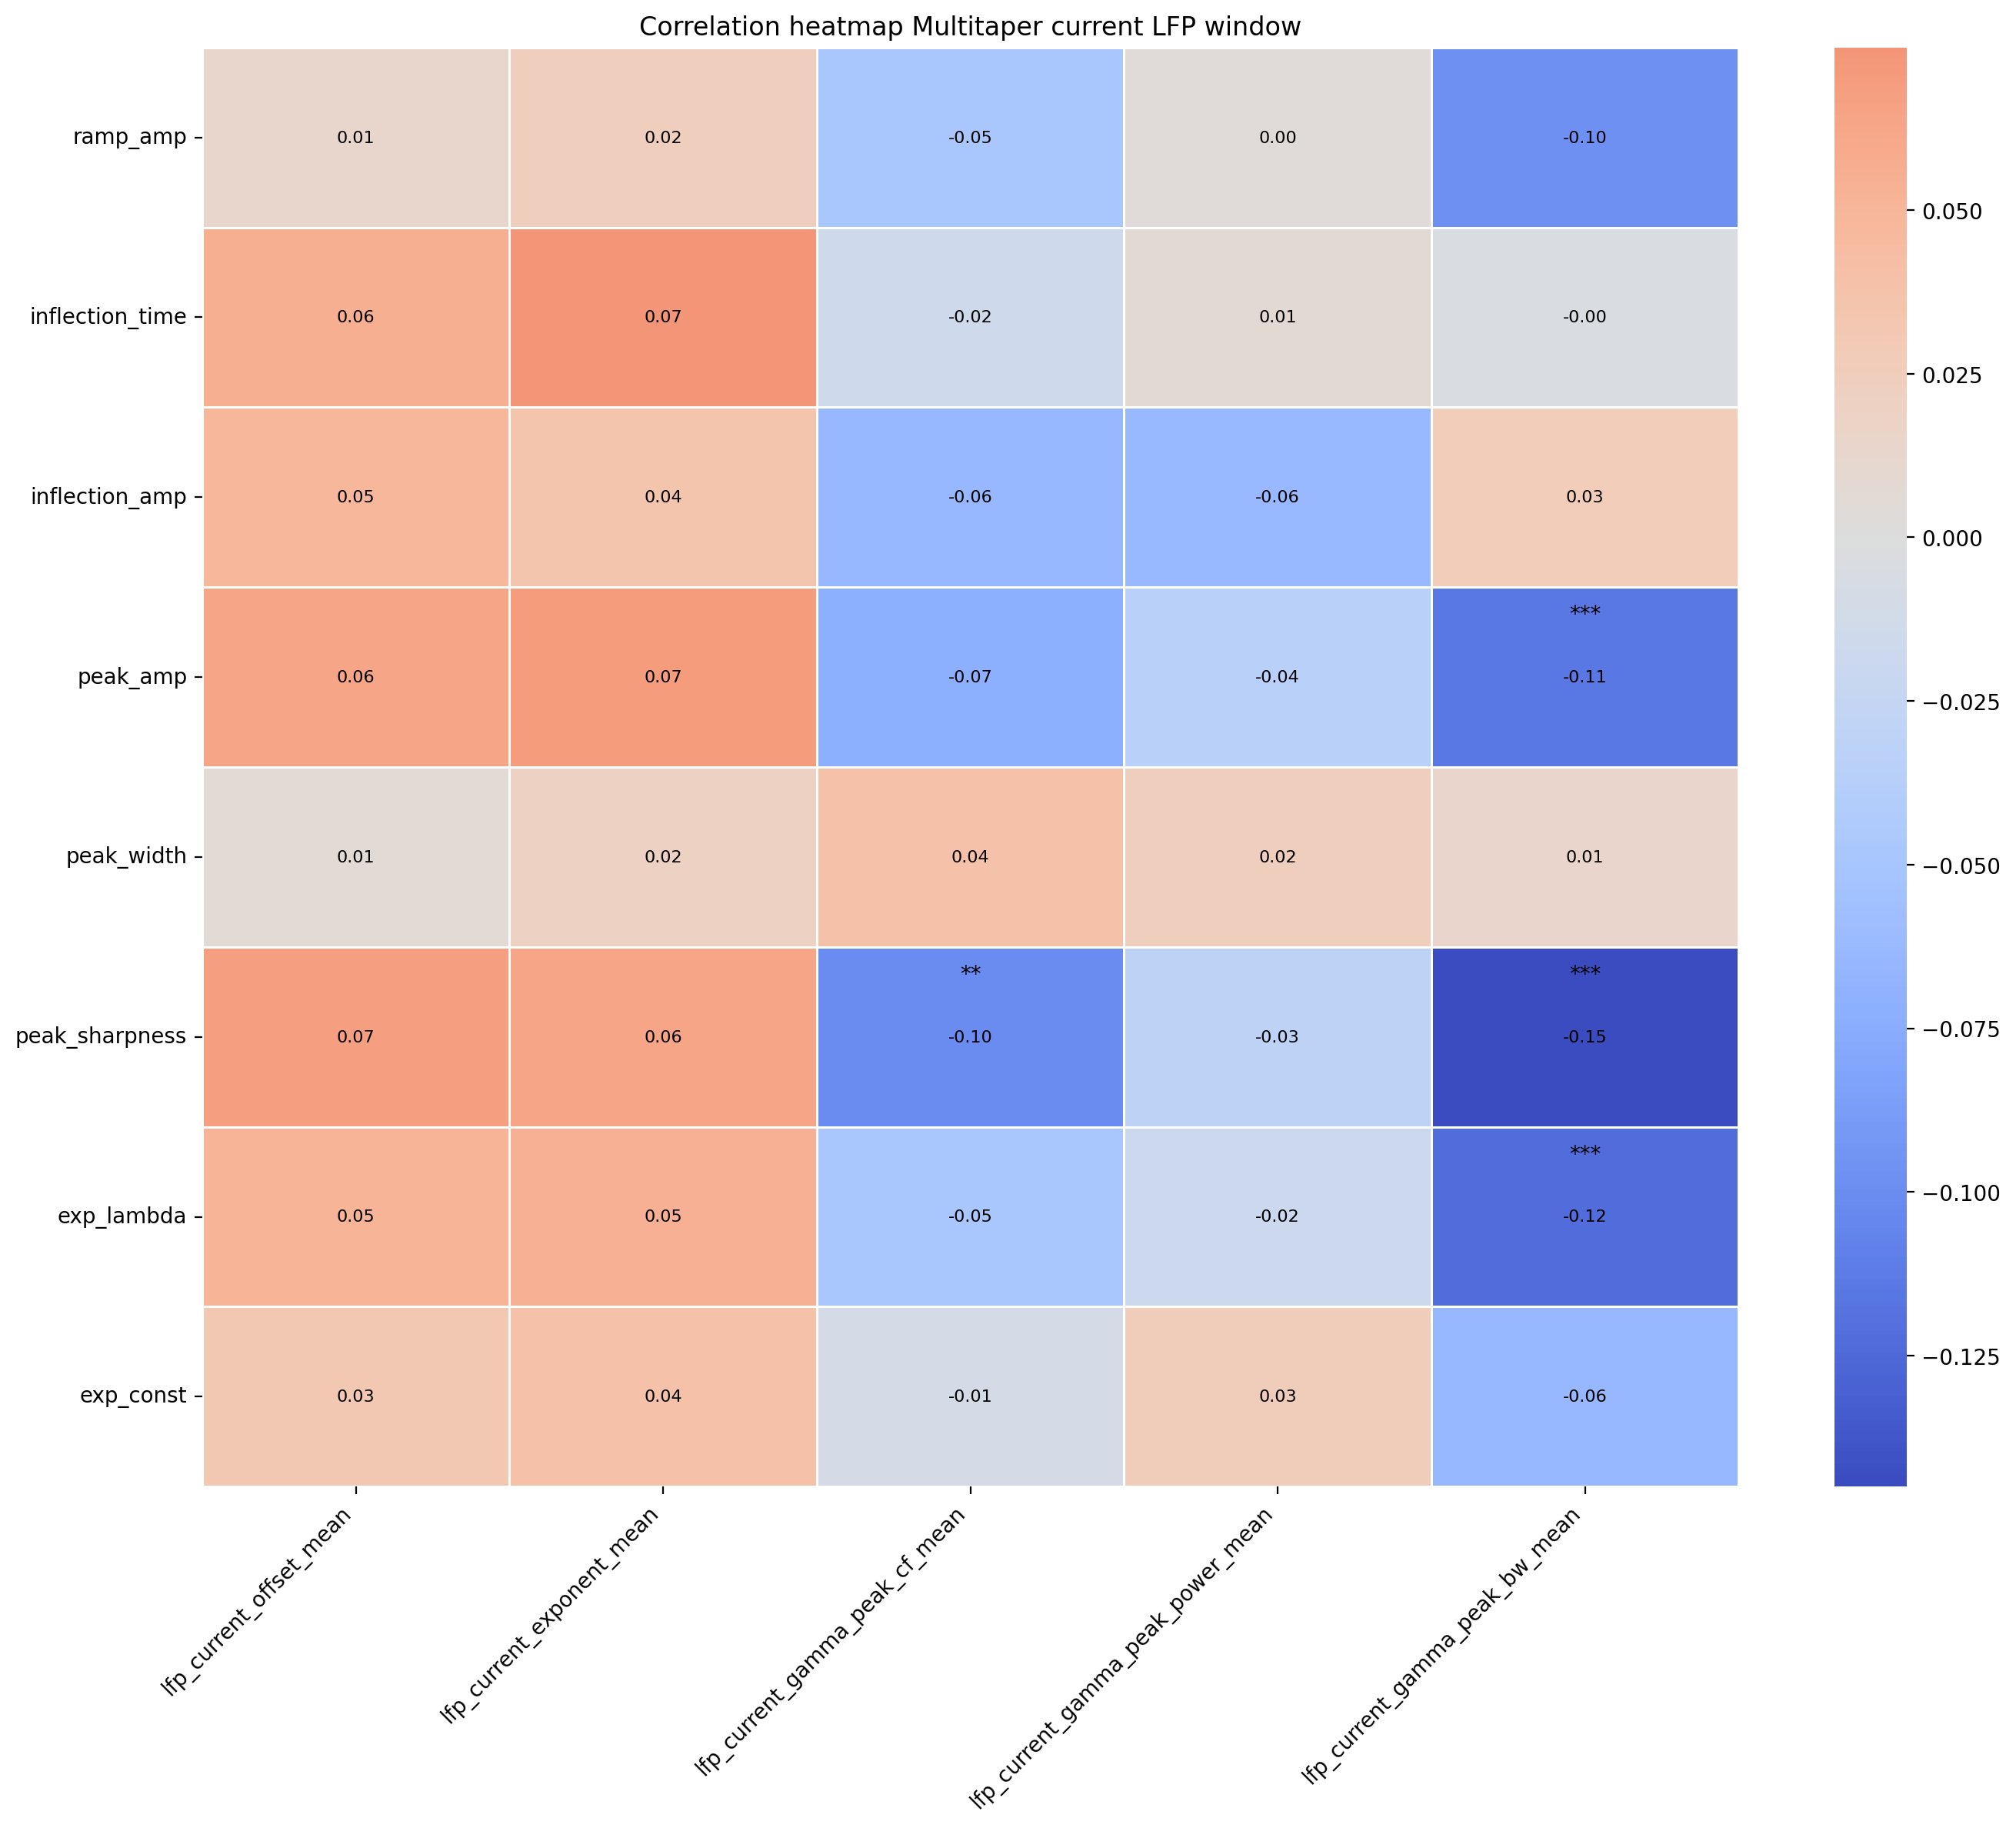

In [40]:
valid_lfp_features = [col for col in lfp_features_current_mean if col in df_current_lfp_processed_multit.columns]
valid_spk_features = [col for col in spike_features if col in df_current_lfp_processed_multit.columns]

plot_lfp_spk_correlation_heatmap(
    df_current_lfp_processed_multit,
    valid_spk_features ,
    valid_lfp_features,  title = "Correlation heatmap Multitaper current LFP window")


In [41]:
df_current_lfp_processed_welch

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,...,lfp_current_theta_peak_bw_mean,lfp_current_alpha_peak_power_mean,lfp_current_alpha_peak_cf_mean,lfp_current_alpha_peak_bw_mean,lfp_current_beta_peak_power_mean,lfp_current_beta_peak_cf_mean,lfp_current_beta_peak_bw_mean,lfp_current_gamma_peak_power_mean,lfp_current_gamma_peak_cf_mean,lfp_current_gamma_peak_bw_mean
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,2.373367,11705,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.002533,46.764754,7.000000
1,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,2.988771,23523,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.101301,47.149598,7.333333
2,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,1.798995,72270,...,4.000000,0.746192,9.000002,8.0,0.878033,19.594632,6.666667,1.055915,45.486643,6.958241
4,1.131318,0.72,3.423346,26.219775,1.14,0.626201,1.488794,3.536553,3.134033,81424,...,4.000000,0.746192,9.000002,8.0,0.878033,19.594632,6.666667,1.042777,45.291827,6.629548
5,1.095346,0.72,3.602710,27.026259,1.20,0.577308,1.179299,3.795708,2.170699,149534,...,6.666667,0.746192,9.000002,8.0,0.878033,19.594632,6.666667,1.001624,44.348779,4.731084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1412,0.419223,0.74,1.372701,8.222671,2.70,0.136387,0.618987,3.460899,2.244713,40208636,...,NaN,NaN,NaN,NaN,0.768630,17.450858,4.000000,1.204345,46.580427,6.816974
1413,0.519763,0.74,2.010334,8.162258,2.22,0.076964,0.727547,3.676848,3.227047,40217424,...,NaN,NaN,NaN,NaN,0.771397,20.141612,5.000000,1.204668,46.754792,7.016974
1414,0.408720,0.70,2.936752,9.357549,2.00,0.152990,0.277083,1.381203,2.271959,40301801,...,NaN,NaN,NaN,NaN,0.722745,27.481392,5.364930,1.192746,47.128057,6.219037
1415,0.128864,0.76,1.236059,7.619188,1.88,0.090531,0.617930,2.007826,3.543086,40311158,...,NaN,1.135421,11.892386,4.0,0.793962,26.382706,4.364930,1.192638,47.206595,6.019037


In [42]:
df_current_lfp_processed_multit

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,lfp_current_offset_mean,lfp_current_exponent_mean,lfp_current_error_mean,lfp_current_gamma_peak_power_mean,lfp_current_gamma_peak_cf_mean,lfp_current_gamma_peak_bw_mean
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,6.339220,2.366572,0.388793,0.760640,43.871398,5.999995
1,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,6.304204,2.340195,0.398069,0.807350,44.105143,5.999997
2,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,6.648273,2.567236,0.412015,0.884196,44.718981,6.338266
4,1.131318,0.72,3.423346,26.219775,1.14,0.626201,1.488794,3.536553,6.696044,2.601454,0.416973,0.892588,44.264700,6.249428
5,1.095346,0.72,3.602710,27.026259,1.20,0.577308,1.179299,3.795708,6.750351,2.643079,0.429596,0.918868,45.097556,6.161074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1412,0.419223,0.74,1.372701,8.222671,2.70,0.136387,0.618987,3.460899,6.854023,2.631433,0.401909,1.288693,45.419397,6.620818
1413,0.519763,0.74,2.010334,8.162258,2.22,0.076964,0.727547,3.676848,6.901053,2.653732,0.394153,1.228083,46.222369,6.420818
1414,0.408720,0.70,2.936752,9.357549,2.00,0.152990,0.277083,1.381203,6.861948,2.697144,0.413750,1.217855,48.108246,6.377258
1415,0.128864,0.76,1.236059,7.619188,1.88,0.090531,0.617930,2.007826,6.854182,2.709771,0.422041,1.243331,47.855170,6.282672


In [43]:
valid_lfp_features

['lfp_current_offset_mean',
 'lfp_current_exponent_mean',
 'lfp_current_gamma_peak_cf_mean',
 'lfp_current_gamma_peak_power_mean',
 'lfp_current_gamma_peak_bw_mean']

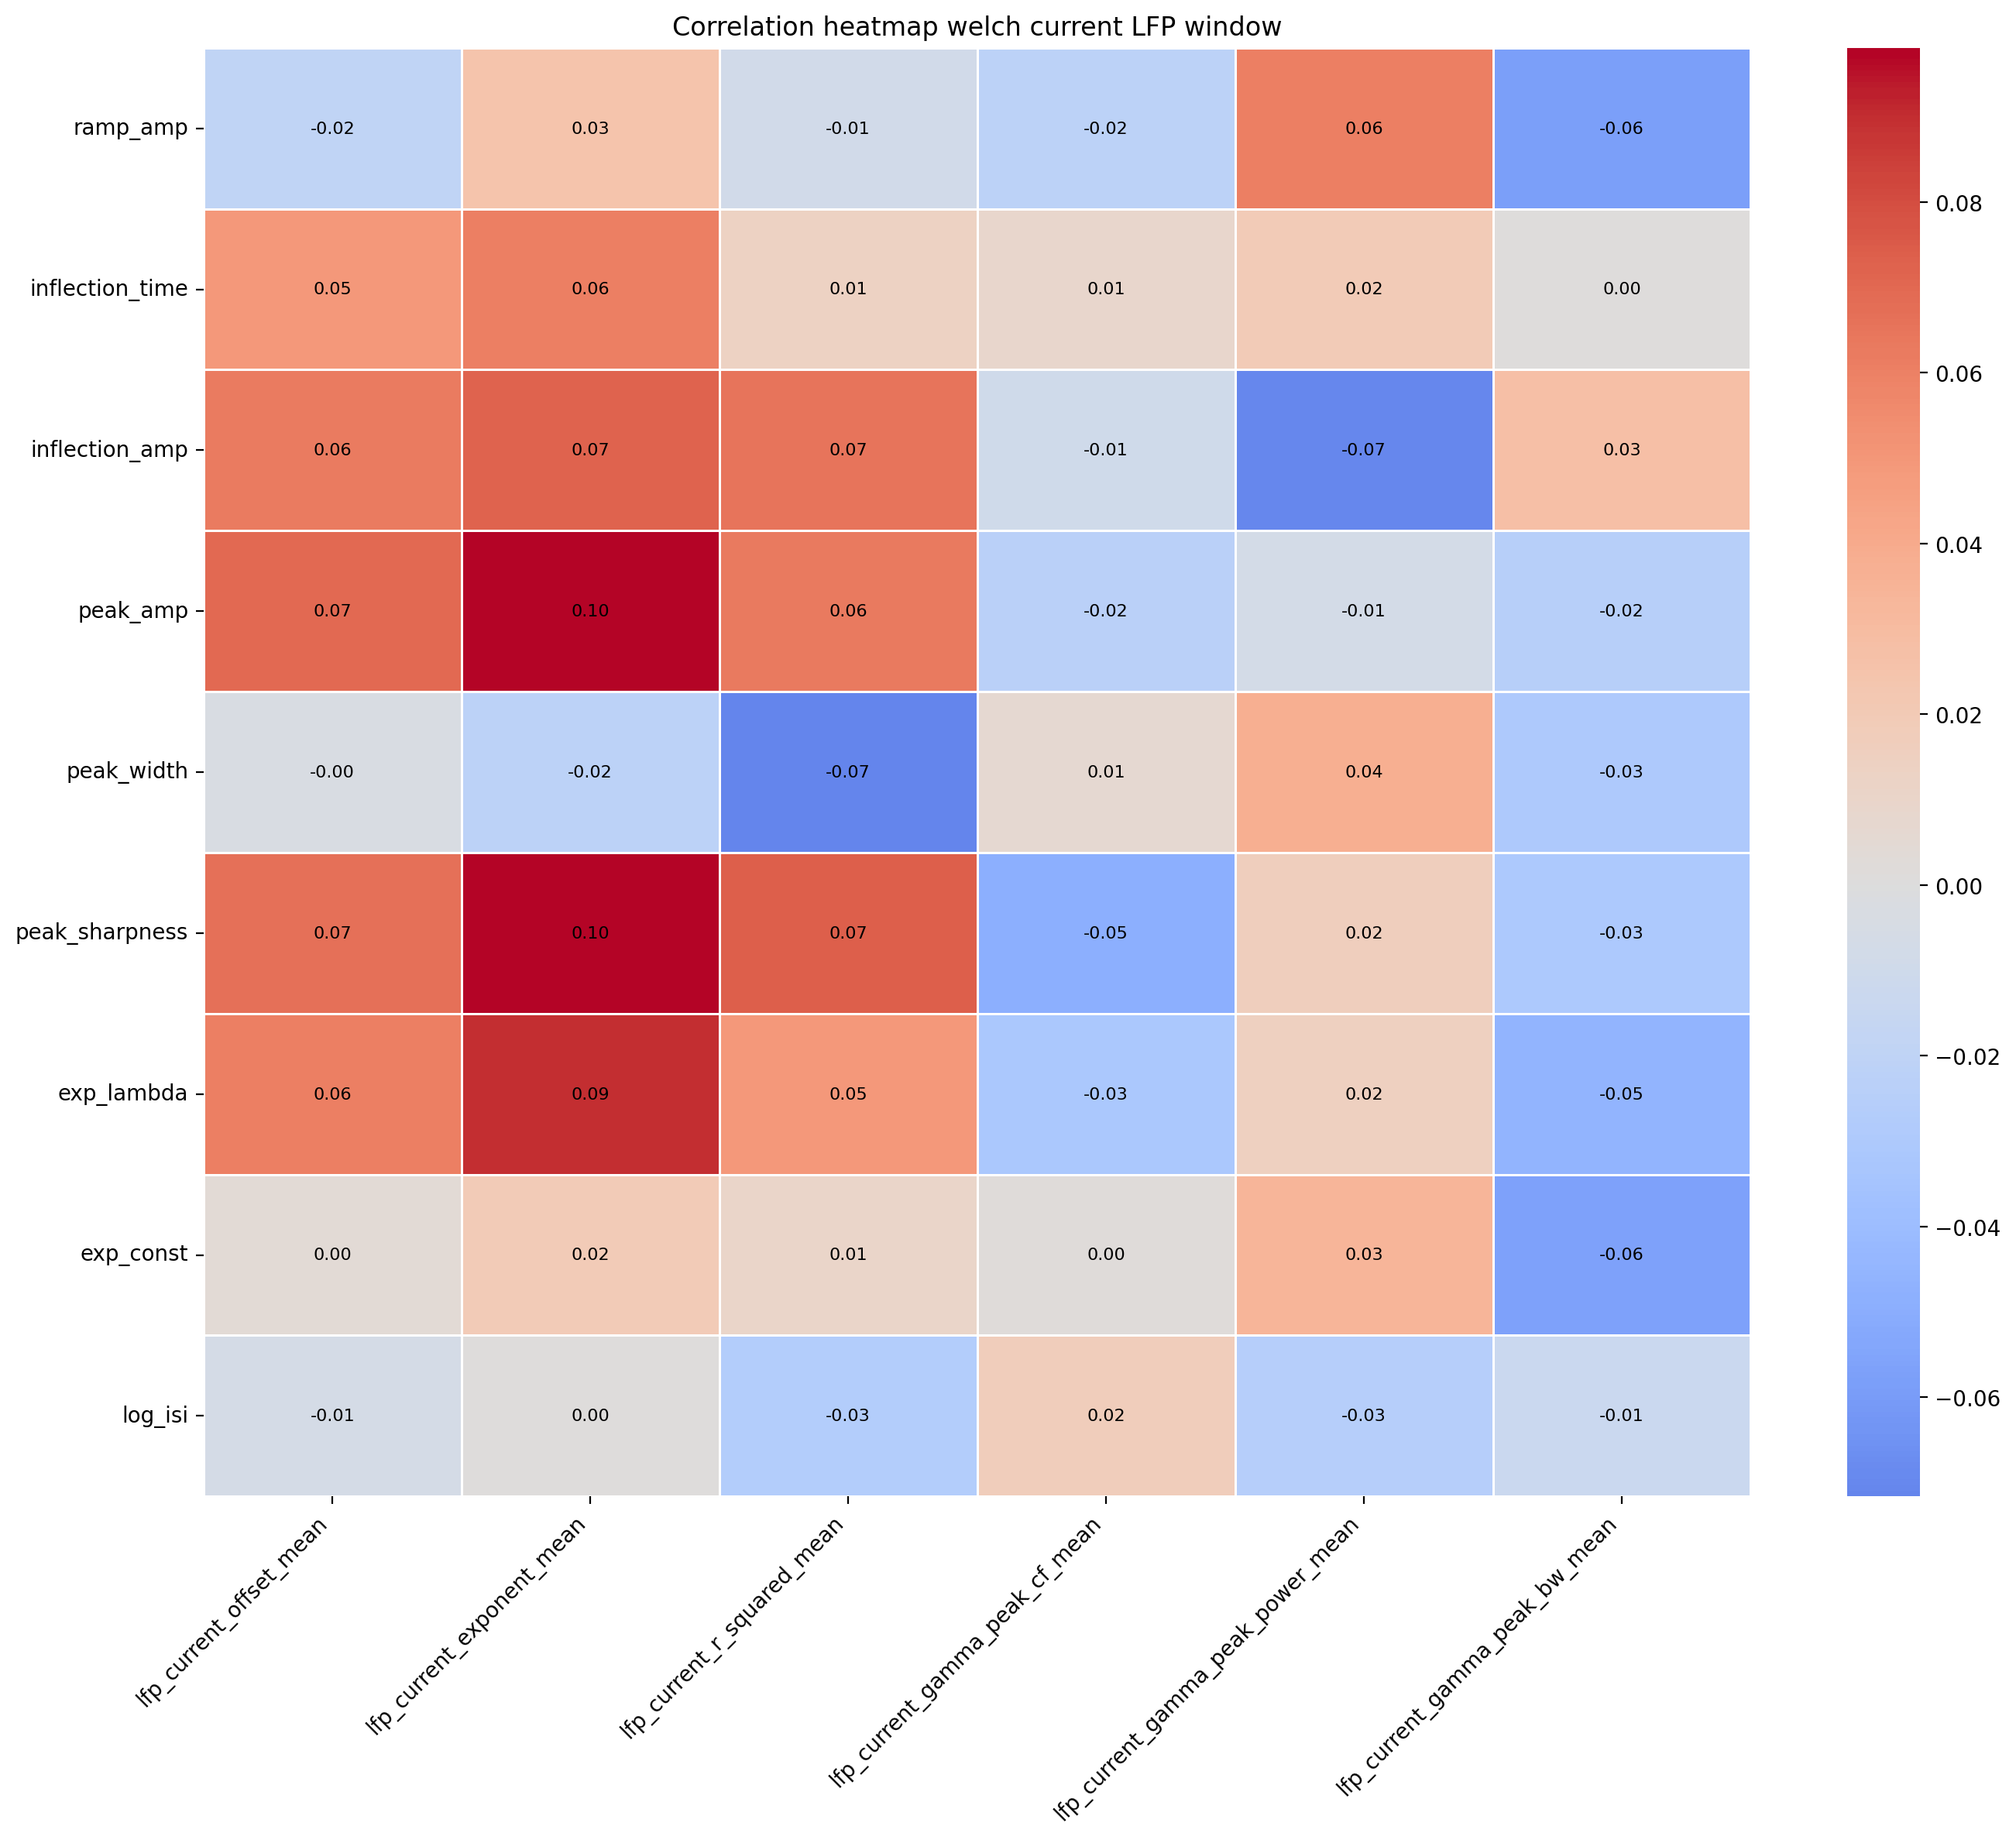

In [44]:
valid_lfp_features = [col for col in lfp_features_current_mean if col in df_current_lfp_processed_welch.columns]
valid_spk_features = [col for col in spike_features if col in df_current_lfp_processed_welch.columns]

plot_lfp_spk_correlation_heatmap(
    df_current_lfp_processed_welch,
    valid_spk_features ,
    valid_lfp_features,  title = "Correlation heatmap welch current LFP window")


## STEP 6: Sensitivity analysis - see effects of welch vs multitaper with variation of hyperparameters for psd generation + fooof fitting

In [45]:

# ----------------------------------------
# Run sensitivity analysis on LFP windows
# ----------------------------------------
freq_range      = (1, 90)
window_lengths  = [1.0, 2.0, 5.0]
methods         = ["multitaper", "welch"]           # compare both
time_bandwidths = [2.0, 4.0, 6.0, 8.0]              # NW sweep
fooof_param_grid = [
    {"peak_width_limits": (4, 8), "max_n_peaks": 4, "aperiodic_mode": "fixed", "verbose": False},
]

# 75% overlap => hop = window_length * 0.25
sensitivity_results_df, foof_by_config = sensitivity_analysis(
    lfp_signal=lfp_filt,
    fs=lfp_fs,
    freq_range=freq_range,
    window_lengths=window_lengths,
    methods=methods,
    time_bandwidths=time_bandwidths,
    fooof_param_grid=fooof_param_grid,
    step_ratio=0.25,     # 1s→0.25s hop, 2s→0.5s, 5s→1.25s
    n_freqs=256,
    verbose=True,
)


Param combos:   0%|          | 0/24 [00:00<?, ?it/s]

[SKIPPED] 59abf8c9 due to: compute_lfp_windows() got an unexpected keyword argument 'step_size_sec'
[SKIPPED] 3da5aa5a due to: compute_lfp_windows() got an unexpected keyword argument 'step_size_sec'
[SKIPPED] 941fbb65 due to: compute_lfp_windows() got an unexpected keyword argument 'step_size_sec'
[SKIPPED] 3dec1297 due to: compute_lfp_windows() got an unexpected keyword argument 'step_size_sec'
[SKIPPED] 334adb92 due to: compute_lfp_windows() got an unexpected keyword argument 'step_size_sec'
[SKIPPED] 7e090f2a due to: compute_lfp_windows() got an unexpected keyword argument 'step_size_sec'
[SKIPPED] 4042eb9b due to: compute_lfp_windows() got an unexpected keyword argument 'step_size_sec'
[SKIPPED] 2f83cad1 due to: compute_lfp_windows() got an unexpected keyword argument 'step_size_sec'
[SKIPPED] 1d567c47 due to: compute_lfp_windows() got an unexpected keyword argument 'step_size_sec'
[SKIPPED] c844c4e4 due to: compute_lfp_windows() got an unexpected keyword argument 'step_size_sec'


In [46]:
"""
#Save as pickle - comment out 
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/sensitivity_results_df', 'wb') as file: 
    pickle.dump(sensitivity_results_df, file) 

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/foof_by_config', 'wb') as file: 
    pickle.dump(foof_by_config, file) """

"\n#Save as pickle - comment out \nwith open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/sensitivity_results_df', 'wb') as file: \n    pickle.dump(sensitivity_results_df, file) \n\nwith open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/foof_by_config', 'wb') as file: \n    pickle.dump(foof_by_config, file) "

In [47]:
#Load pickle file 
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/sensitivity_results_df', 'rb') as file:
    sensitivity_results_df = pickle.load(file)

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/foof_by_config', 'rb') as file:
    foof_by_config = pickle.load(file)

In [48]:
sensitivity_results_df

,window_start,window_end,aperiodic_offset,aperiodic_exponent,r_squared,n_peaks,peak_cf_0,peak_pw_0,peak_bw_0,peak_cf_1,...,gamma_peak_cf,gamma_peak_bw,config_id,window_length_sec,step_size_sec,method,time_bandwidth,max_n_peaks,peak_threshold,aperiodic_mode
0,0,25000,3.710978,2.702634,0.867930,2,45.499194,0.864706,7.312131,56.000000,...,50.749597,7.656065,fa11214a,10,5.0,welch,2.0,2,1.5,fixed
1,12500,37500,3.683468,2.660196,0.881645,1,50.060685,0.931066,8.000000,NaN,...,50.060685,8.000000,fa11214a,10,5.0,welch,2.0,2,1.5,fixed
2,25000,50000,3.798415,2.714691,0.877144,2,38.750000,0.815026,8.000000,55.171100,...,46.960550,8.000000,fa11214a,10,5.0,welch,2.0,2,1.5,fixed
3,37500,62500,3.582878,2.629803,0.878930,2,40.267871,1.166162,8.000000,53.467426,...,46.867648,8.000000,fa11214a,10,5.0,welch,2.0,2,1.5,fixed
4,50000,75000,3.204630,2.364187,0.851066,1,44.113876,1.167236,8.000000,NaN,...,44.113876,8.000000,fa11214a,10,5.0,welch,2.0,2,1.5,fixed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21163,1800000,1875000,7.270912,1.230612,0.994468,2,45.984500,0.490136,8.000000,57.049880,...,51.517190,8.000000,69185231,30,15.0,multitaper,6.0,4,2.0,knee
21164,1837500,1912500,7.161725,0.553174,0.991716,3,39.437179,0.408697,8.000000,47.917966,...,48.774259,7.910109,69185231,30,15.0,multitaper,6.0,4,2.0,knee
21165,1875000,1950000,7.260474,1.226320,0.994807,3,39.466304,0.418371,8.000000,48.639974,...,49.482591,8.000000,69185231,30,15.0,multitaper,6.0,4,2.0,knee
21166,1912500,1987500,7.321610,2.165476,0.996530,3,40.622025,0.235701,8.000000,49.927388,...,50.467129,8.000000,69185231,30,15.0,multitaper,6.0,4,2.0,knee


In [49]:
sensitivity_results_df.groupby(['method', 'aperiodic_mode', 'window_length_sec'])[
    ['aperiodic_exponent', 'aperiodic_offset', 'gamma_peak_power', 'r_squared']
].describe()


aperiodic_exponent            \
                                                         count      mean   
method     aperiodic_mode window_length_sec                                
multitaper fixed          10                            2898.0  2.446128   
                          20                            1440.0  2.459244   
                          30                             954.0  2.464017   
           knee           10                            2898.0  0.588518   
                          20                            1440.0  0.594315   
                          30                             954.0  0.587291   
welch      fixed          10                            2898.0  2.564659   
                          20                            1440.0  2.545283   
                          30                             954.0  2.523968   
           knee           10                            2898.0  0.152805   
                          20                            1440.0 -0.091161   
                          30                             954.0 -0.174235   

                                                                           \
                                                  std       min       25%   
method     aperiodic_mode window_length_sec                                 
multitaper fixed          10                 0.067489  2.195587  2.406562   
                          20                 0.057401  2.220384  2.425704   
                          30                 0.051225  2.289164  2.433527   
           knee           10                 0.834675 -0.713819 -0.029928   
                          20                 0.736827 -0.632790 -0.025905   
                          30                 0.678040 -0.537666 -0.056805   
welch      fixed          10                 0.137729  1.920983  2.473050   
                          20                 0.084856  2.292079  2.486408   
                          30                 0.080050  2.314793  2.464430   
           knee           10                 2.308782 -0.905729 -0.661607   
                          20                 0.606335 -0.746948 -0.479709   
                          30                 0.461400 -0.764539 -0.458451   

                                                                            \
                                                  50%       75%        max   
method     aperiodic_mode window_length_sec                                  
multitaper fixed          10                 2.453692  2.492874   2.621470   
                          20                 2.464354  2.500478   2.579043   
                          30                 2.470095  2.501116   2.577341   
           knee           10                 0.470720  1.046751   4.957801   
                          20                 0.546489  1.072118   3.150494   
                          30                 0.590284  1.073655   2.284524   
welch      fixed          10                 2.569123  2.655093   2.886764   
                          20                 2.561562  2.613451   2.708540   
                          30                 2.523815  2.576348   2.736185   
           knee           10                -0.406539  0.112288  32.090998   
                          20                -0.313645  0.081132   2.530765   
                          30                -0.303125 -0.037477   2.005914   

                                            aperiodic_offset            ...  \
                                                       count      mean  ...   
method     aperiodic_mode window_length_sec                             ...   
multitaper fixed          10                          2898.0  7.026347  ...   
                          20                          1440.0  7.051849  ...   
                          30                           954.0  7.058048  ...   
           knee           10                          2898.0  7.077636  ...   
                       

In [50]:
### Only show window length comparison
sensitivity_results_df.groupby(['method', 'window_length_sec'])[
    ['aperiodic_exponent', 'aperiodic_offset', 'gamma_peak_power']
].describe()



aperiodic_exponent                                \
                                          count      mean       std       min   
method     window_length_sec                                                    
multitaper 10                            5796.0  1.517323  1.101538 -0.713819   
           20                            2880.0  1.526779  1.069019 -0.632790   
           30                            1908.0  1.525654  1.054536 -0.537666   
welch      10                            5796.0  1.358732  2.031938 -0.905729   
           20                            2880.0  1.227061  1.387684 -0.746948   
           30                            1908.0  1.174866  1.389468 -0.764539   

                                                                       \
                                   25%       50%       75%        max   
method     window_length_sec                                            
multitaper 10                 0.470720  2.312649  2.457209   4.957801   
           20                 0.547294  2.328730  2.465850   3.150494   
           30                 0.592567  2.286844  2.470027   2.577341   
welch      10                -0.406539  2.356803  2.587084  32.090998   
           20                -0.313302  2.305075  2.561505   2.708540   
           30                -0.303125  2.160353  2.523815   2.736185   

                             aperiodic_offset            ...            \
                                        count      mean  ...       75%   
method     window_length_sec                             ...             
multitaper 10                          5796.0  7.051991  ...  7.138575   
           20                          2880.0  7.077388  ...  7.158563   
           30                          1908.0  7.084431  ...  7.156729   
welch      10                          5796.0  3.480476  ...  3.619057   
           20                          2880.0  3.573783  ...  3.655355   
           30                          1908.0  3.571292  ...  3.622843   

                                       gamma_peak_power                      \
                                   max            count      mean       std   
method     window_length_sec                                                  
multitaper 10                 7.482744           5676.0  0.447979  0.107786   
           20                 7.478210           2850.0  0.429306  0.093741   
           30                 7.442556           1896.0  0.424495  0.088971   
welch      10                 4.253684           5616.0  0.756788  0.140362   
           20                 3.980229           2880.0  0.576791  0.088606   
           30                 3.966953           1908.0  0.527182  0.084329   

                                                                                
                                   min       25%       50%       75%       max  
method     window_length_sec                                                    
multitaper 10                 0.193078  0.369897  0.430921  0.504958  0.910886  
           20                 0.208579  0.362616  0.412659  0.486927  0.771789  
           30                 0.224690  0.364499  0.404706  0.479647  0.797985  
welch      10                 0.458322  0.660675  0.736094  0.838460  1.330654  
           20                 0.369407  0.503861  0.565826  0.632640  0.915520  
           30                 0.368956  0.470303  0.518939  0.571026  0.890140  

[6 rows x 24 columns]

### Plot fooof fits - aside

In [51]:
"""
save_foof_fit_examples(
    foof_by_config,
    output_dir="foof_fit_plots",
    n_examples=3  # how many example plots per config
)
"""

'\nsave_foof_fit_examples(\n    foof_by_config,\n    output_dir="foof_fit_plots",\n    n_examples=3  # how many example plots per config\n)\n'

In [52]:
#plot_fits_near_global_mean_and_outliers(sensitivity_results_df, foof_by_config)

In [53]:
#plot_fits_near_global_mean_and_outliers(sensitivity_results_df, foof_by_config, metric="gamma_peak_power")